In [6]:
# ============================================================
#  TELECOM CUSTOMER CHURN ANALYSIS
#  Phase 2 — Exploratory Data Analysis (EDA)
#  Dataset: WA_Fn-UseC_-Telco-Customer-Churn.csv
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
# ── Global style ─────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
 
CHURN_PALETTE = {'No': '#1D9E75', 'Yes': '#E24B4A'}
C_GREEN = '#1D9E75'
C_RED   = '#E24B4A'
C_BLUE  = '#185FA5'
C_ORG   = '#EF9F27'

In [8]:
# ── Load & quick-fix ─────────────────────────────────────────
df = pd.read_csv('telco_churn_cleaned.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn_num']    = df['Churn'].map({'Yes': 1, 'No': 0})
 
print("✅ Data loaded")
print(f"   Shape       : {df.shape}")
print(f"   Churn rate  : {df['Churn_num'].mean()*100:.1f}%\n")
 

✅ Data loaded
   Shape       : (7043, 22)
   Churn rate  : 26.5%



Text(0.5, 1.02, 'Chart 1 — Churn Distribution Overview')

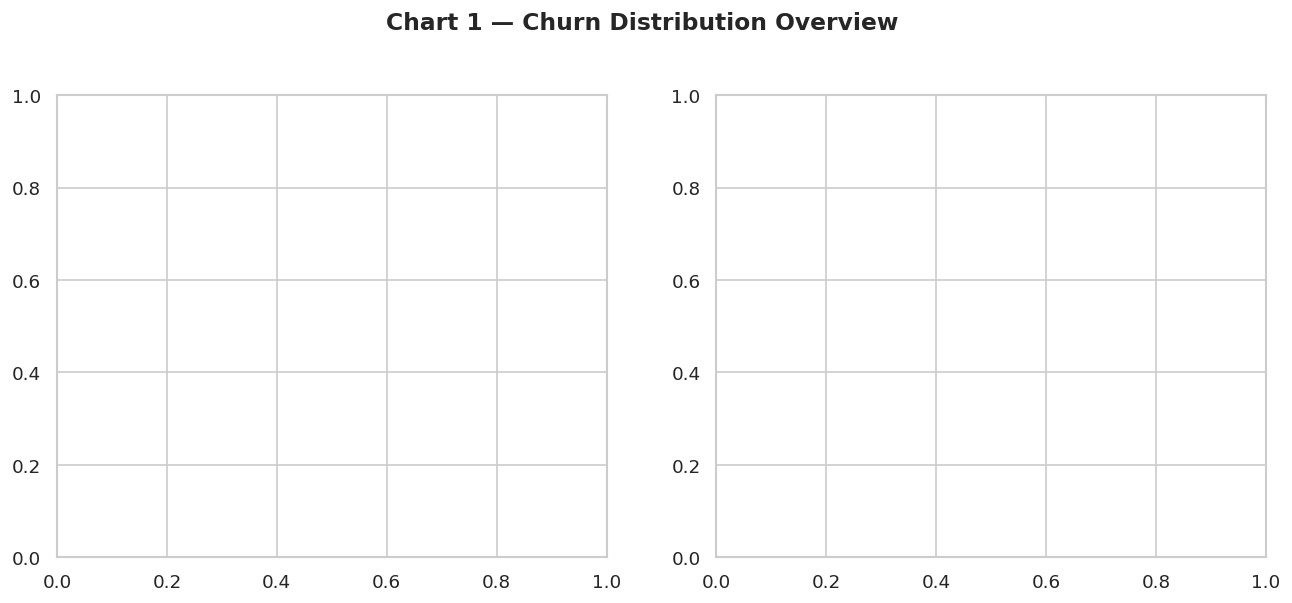

In [9]:
# ════════════════════════════════════════════════════════════
#  CHART 1 — Churn Distribution (Pie + Bar)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 1 — Churn Distribution Overview', fontsize=14, fontweight='bold', y=1.02)

In [10]:
# Pie chart
counts = df['Churn'].value_counts()
axes[0].pie(
    counts,
    labels=['Retained (73.5%)', 'Churned (26.5%)'],
    colors=[C_GREEN, C_RED],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3},
    textprops={'fontsize': 12}
)
axes[0].set_title('Overall Churn Split', fontweight='bold')

Text(0.5, 1.0, 'Overall Churn Split')

In [11]:
# Annotated bar chart
bars = axes[1].bar(['Retained', 'Churned'], counts.values,
                    color=[C_GREEN, C_RED], width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Customer Counts', fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_ylim(0, counts.max() * 1.15)
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('chart1_churn_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 1 saved — chart1_churn_distribution.png")

<Figure size 768x576 with 0 Axes>

✅ Chart 1 saved — chart1_churn_distribution.png


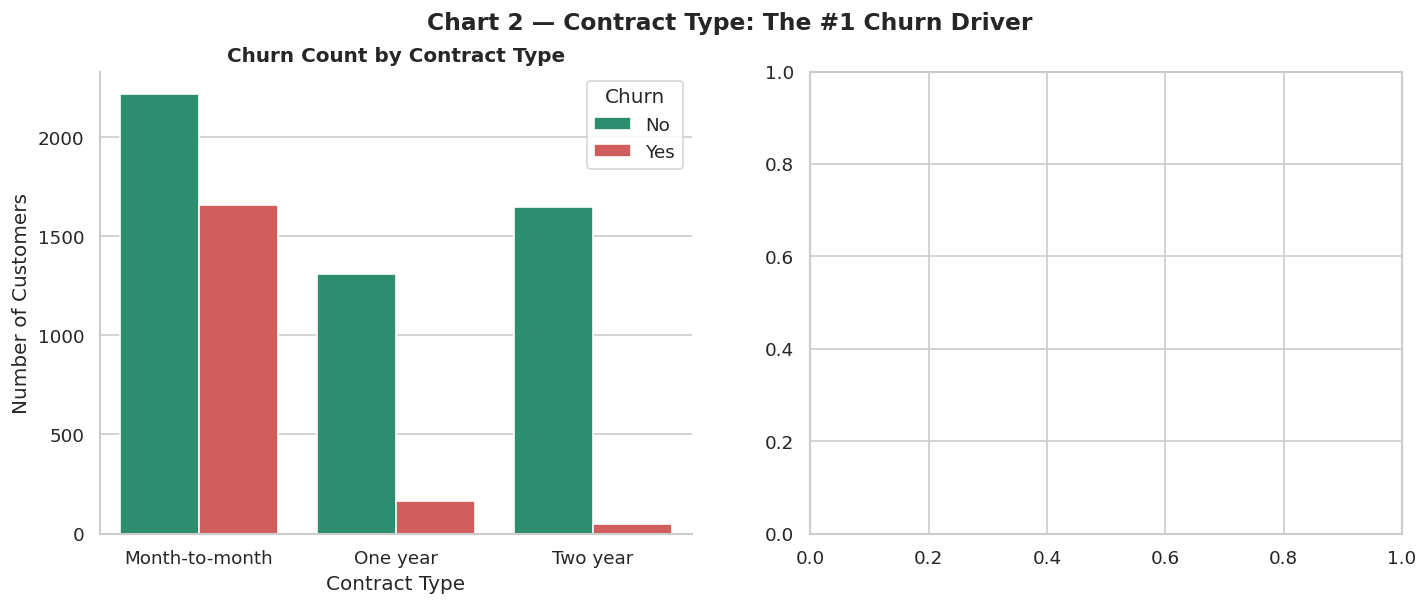

In [12]:
# ════════════════════════════════════════════════════════════
#  CHART 2 — Contract Type vs Churn  (HEADLINE INSIGHT)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 2 — Contract Type: The #1 Churn Driver', fontsize=14, fontweight='bold')
 
# Grouped bar
sns.countplot(x='Contract', hue='Churn', data=df,
              palette=CHURN_PALETTE, ax=axes[0], edgecolor='white')
axes[0].set_title('Churn Count by Contract Type', fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn')
sns.despine(ax=axes[0])

In [13]:
# Churn RATE bar (the cleaner story)
contract_churn = df.groupby('Contract')['Churn_num'].mean() * 100
colors = [C_RED if v > 30 else C_ORG if v > 10 else C_GREEN
          for v in contract_churn.values]
bars = axes[1].bar(contract_churn.index, contract_churn.values,
                    color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, contract_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Churn RATE by Contract Type', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)
axes[1].axhline(26.5, linestyle='--', color='grey', alpha=0.6, label='Avg churn 26.5%')
axes[1].legend()
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('chart2_contract_churn.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 2 saved — chart2_contract_churn.png")
print("   🔑 Key insight: Month-to-month = 42.7%  |  Two year = 2.8%")

<Figure size 768x576 with 0 Axes>

✅ Chart 2 saved — chart2_contract_churn.png
   🔑 Key insight: Month-to-month = 42.7%  |  Two year = 2.8%


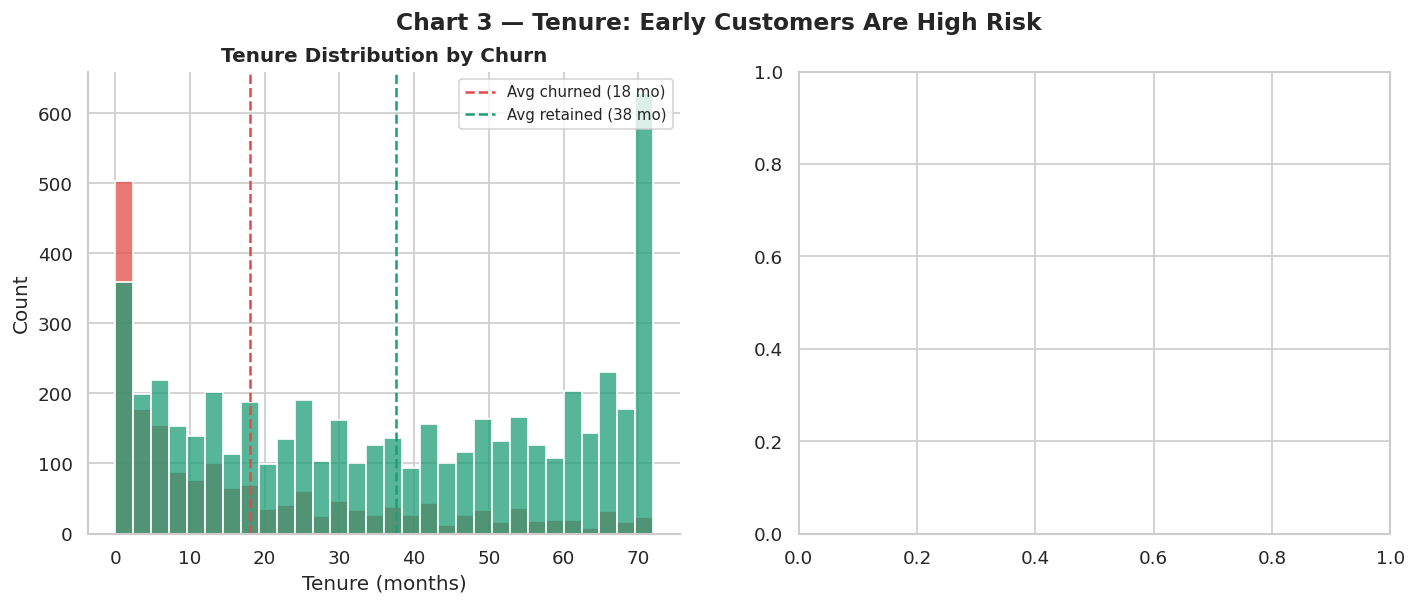

In [14]:
# ════════════════════════════════════════════════════════════
#  CHART 3 — Tenure Analysis
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 3 — Tenure: Early Customers Are High Risk', fontsize=14, fontweight='bold')
 
# Histogram
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette=CHURN_PALETTE, ax=axes[0], alpha=0.75, edgecolor='white')
axes[0].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].axvline(17.98, color=C_RED, linestyle='--', label='Avg churned (18 mo)')
axes[0].axvline(37.57, color=C_GREEN, linestyle='--', label='Avg retained (38 mo)')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

In [15]:
 #Tenure buckets churn rate
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 36, 48, 60, 72],
                             labels=['0–12', '13–24', '25–36', '37–48', '49–60', '61–72'])
tenure_churn = df.groupby('tenure_group', observed=True)['Churn_num'].mean() * 100
colors_t = [C_RED if v > 30 else C_ORG if v > 20 else C_GREEN for v in tenure_churn.values]
bars = axes[1].bar(tenure_churn.index.astype(str), tenure_churn.values,
                    color=colors_t, edgecolor='white', width=0.6)
for bar, val in zip(bars, tenure_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 60)
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('chart3_tenure_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 3 saved — chart3_tenure_analysis.png")
print("   🔑 Key insight: Churned customers avg 18 months vs 38 months for retained")

<Figure size 768x576 with 0 Axes>

✅ Chart 3 saved — chart3_tenure_analysis.png
   🔑 Key insight: Churned customers avg 18 months vs 38 months for retained


Text(0, 0.5, 'Monthly Charges ($)')

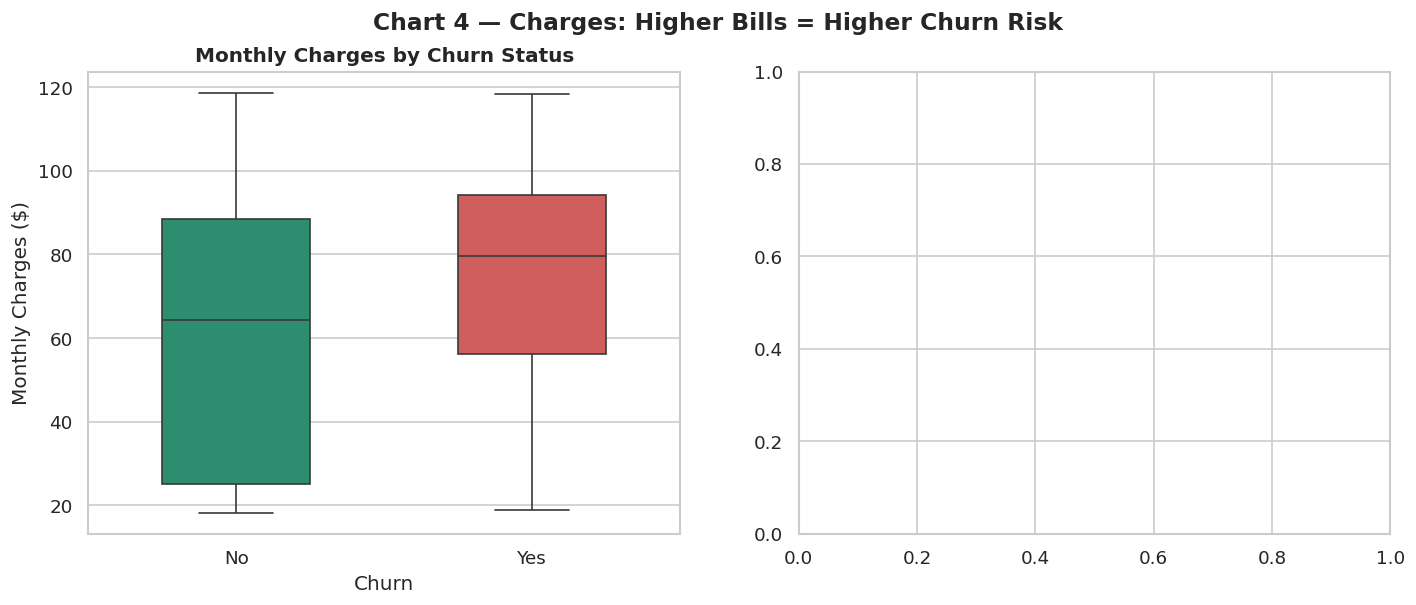

In [16]:
# ════════════════════════════════════════════════════════════
#  CHART 4 — Monthly Charges & Total Charges
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 4 — Charges: Higher Bills = Higher Churn Risk', fontsize=14, fontweight='bold')
 
# Monthly charges box plot
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette=CHURN_PALETTE, ax=axes[0],
            width=0.5, flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
axes[0].set_title('Monthly Charges by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')

In [17]:
 #Add median labels
for i, churn_val in enumerate(['No', 'Yes']):
    med = df[df['Churn'] == churn_val]['MonthlyCharges'].median()
    axes[0].text(i, med + 1.5, f'Median\n${med:.0f}', ha='center',
                 fontsize=9, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#333', alpha=0.7))
sns.despine(ax=axes[0])

In [18]:
# KDE plot — total charges
for churn_val, color in [('No', C_GREEN), ('Yes', C_RED)]:
    subset = df[df['Churn'] == churn_val]['TotalCharges']
    axes[1].hist(subset, bins=40, alpha=0.55, color=color,
                 label=f'{"Retained" if churn_val=="No" else "Churned"} '
                       f'(avg ${subset.mean():,.0f})',
                 density=True, edgecolor='white')
axes[1].set_title('Total Charges Distribution', fontweight='bold')
axes[1].set_xlabel('Total Charges ($)')
axes[1].set_ylabel('Density')
axes[1].legend()
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('chart4_charges_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 4 saved — chart4_charges_analysis.png")
print("   🔑 Key insight: Churned customers avg $74/mo vs $61/mo retained")
 

<Figure size 768x576 with 0 Axes>

✅ Chart 4 saved — chart4_charges_analysis.png
   🔑 Key insight: Churned customers avg $74/mo vs $61/mo retained


Text(0.5, 0.98, 'Chart 5 — Internet Service & Add-ons Drive Churn')

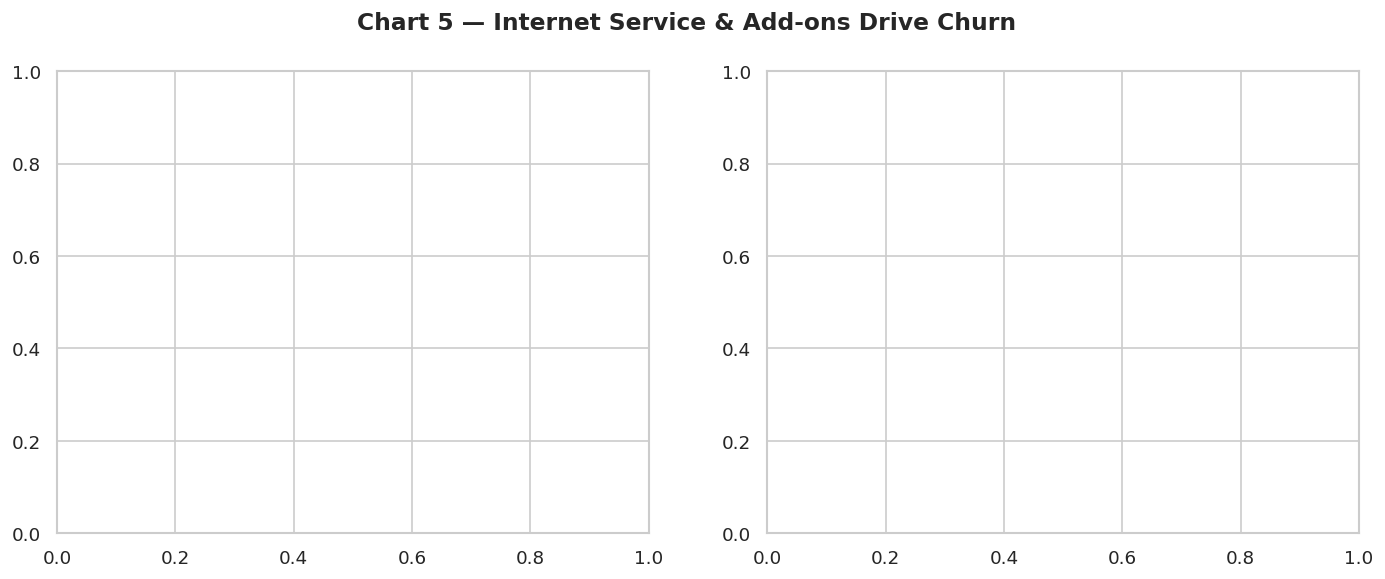

In [19]:
# ════════════════════════════════════════════════════════════
#  CHART 5 — Internet Service & Add-on Services
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 5 — Internet Service & Add-ons Drive Churn', fontsize=14, fontweight='bold')

In [20]:
# Internet service churn rate
internet_churn = df.groupby('InternetService')['Churn_num'].mean() * 100
colors_i = [C_GREEN if v < 20 else C_RED for v in internet_churn.values]
bars = axes[0].bar(internet_churn.index, internet_churn.values,
                    color=colors_i, width=0.5, edgecolor='white')
for bar, val in zip(bars, internet_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].axhline(26.5, linestyle='--', color='grey', alpha=0.6, label='Avg 26.5%')
axes[0].set_title('Churn Rate by Internet Service Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 55)
axes[0].legend()
sns.despine(ax=axes[0])

In [21]:
 #Add-on services churn rate (OnlineSecurity, TechSupport etc.)
addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
addon_churn = {}
for col in addons:
    rate = df[df[col] == 'No']['Churn_num'].mean() * 100
    addon_churn[col.replace('Online', 'Online\n').replace('Device', 'Device\n').replace('Tech', 'Tech\n')] = rate
 
bars2 = axes[1].bar(addon_churn.keys(), addon_churn.values(),
                     color=C_RED, width=0.5, edgecolor='white', alpha=0.85)
for bar, val in zip(bars2, addon_churn.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Churn Rate for Customers WITHOUT Add-on', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)
axes[1].axhline(26.5, linestyle='--', color='grey', alpha=0.6, label='Avg 26.5%')
axes[1].legend()
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('chart5_internet_addons.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 5 saved — chart5_internet_addons.png")
print("   🔑 Key insight: Fiber optic = 41.9% churn | No OnlineSecurity = 41.8% churn")
 

<Figure size 768x576 with 0 Axes>

✅ Chart 5 saved — chart5_internet_addons.png
   🔑 Key insight: Fiber optic = 41.9% churn | No OnlineSecurity = 41.8% churn


Text(0.5, 0.98, 'Chart 6 — Payment Behaviour & Billing Preferences')

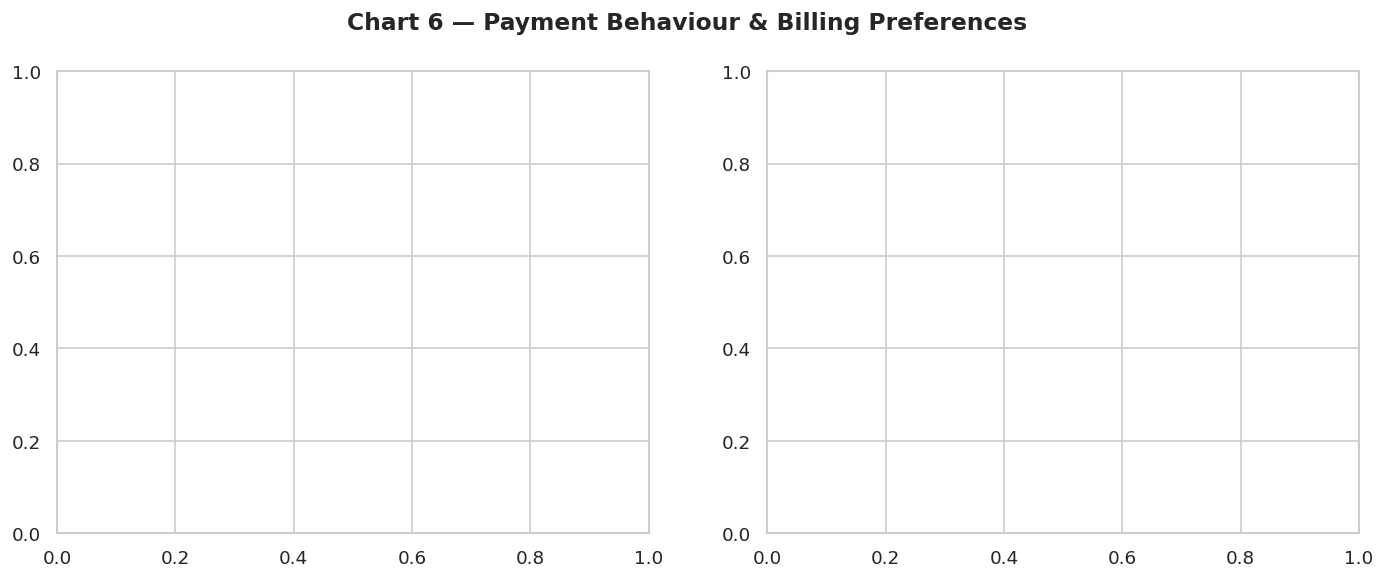

In [22]:
 #════════════════════════════════════════════════════════════
#  CHART 6 — Payment Method & Paperless Billing
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 6 — Payment Behaviour & Billing Preferences', fontsize=14, fontweight='bold')

In [23]:
# Payment method churn rate
pay_churn = df.groupby('PaymentMethod')['Churn_num'].mean() * 100
pay_churn.index = ['Bank\nTransfer', 'Credit\nCard', 'Electronic\nCheck', 'Mailed\nCheck']
colors_p = [C_RED if v > 30 else C_GREEN for v in pay_churn.values]
bars = axes[0].bar(pay_churn.index, pay_churn.values,
                    color=colors_p, width=0.5, edgecolor='white')
for bar, val in zip(bars, pay_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].axhline(26.5, linestyle='--', color='grey', alpha=0.6, label='Avg 26.5%')
axes[0].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 58)
axes[0].legend()
sns.despine(ax=axes[0])

In [24]:
 #Paperless billing
paper_churn = df.groupby('PaperlessBilling')['Churn_num'].mean() * 100
axes[1].pie(
    paper_churn.values,
    labels=[f'No Paperless\n{paper_churn["No"]:.1f}% churn',
            f'Paperless Billing\n{paper_churn["Yes"]:.1f}% churn'],
    colors=[C_GREEN, C_RED],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3},
    textprops={'fontsize': 11}
)
axes[1].set_title('Churn Rate: Paperless vs Traditional Billing', fontweight='bold')
 
plt.tight_layout()
plt.savefig('chart6_payment_billing.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 6 saved — chart6_payment_billing.png")
print("   🔑 Key insight: Electronic check users churn at 45.3% — highest of all")
 

<Figure size 768x576 with 0 Axes>

✅ Chart 6 saved — chart6_payment_billing.png
   🔑 Key insight: Electronic check users churn at 45.3% — highest of all


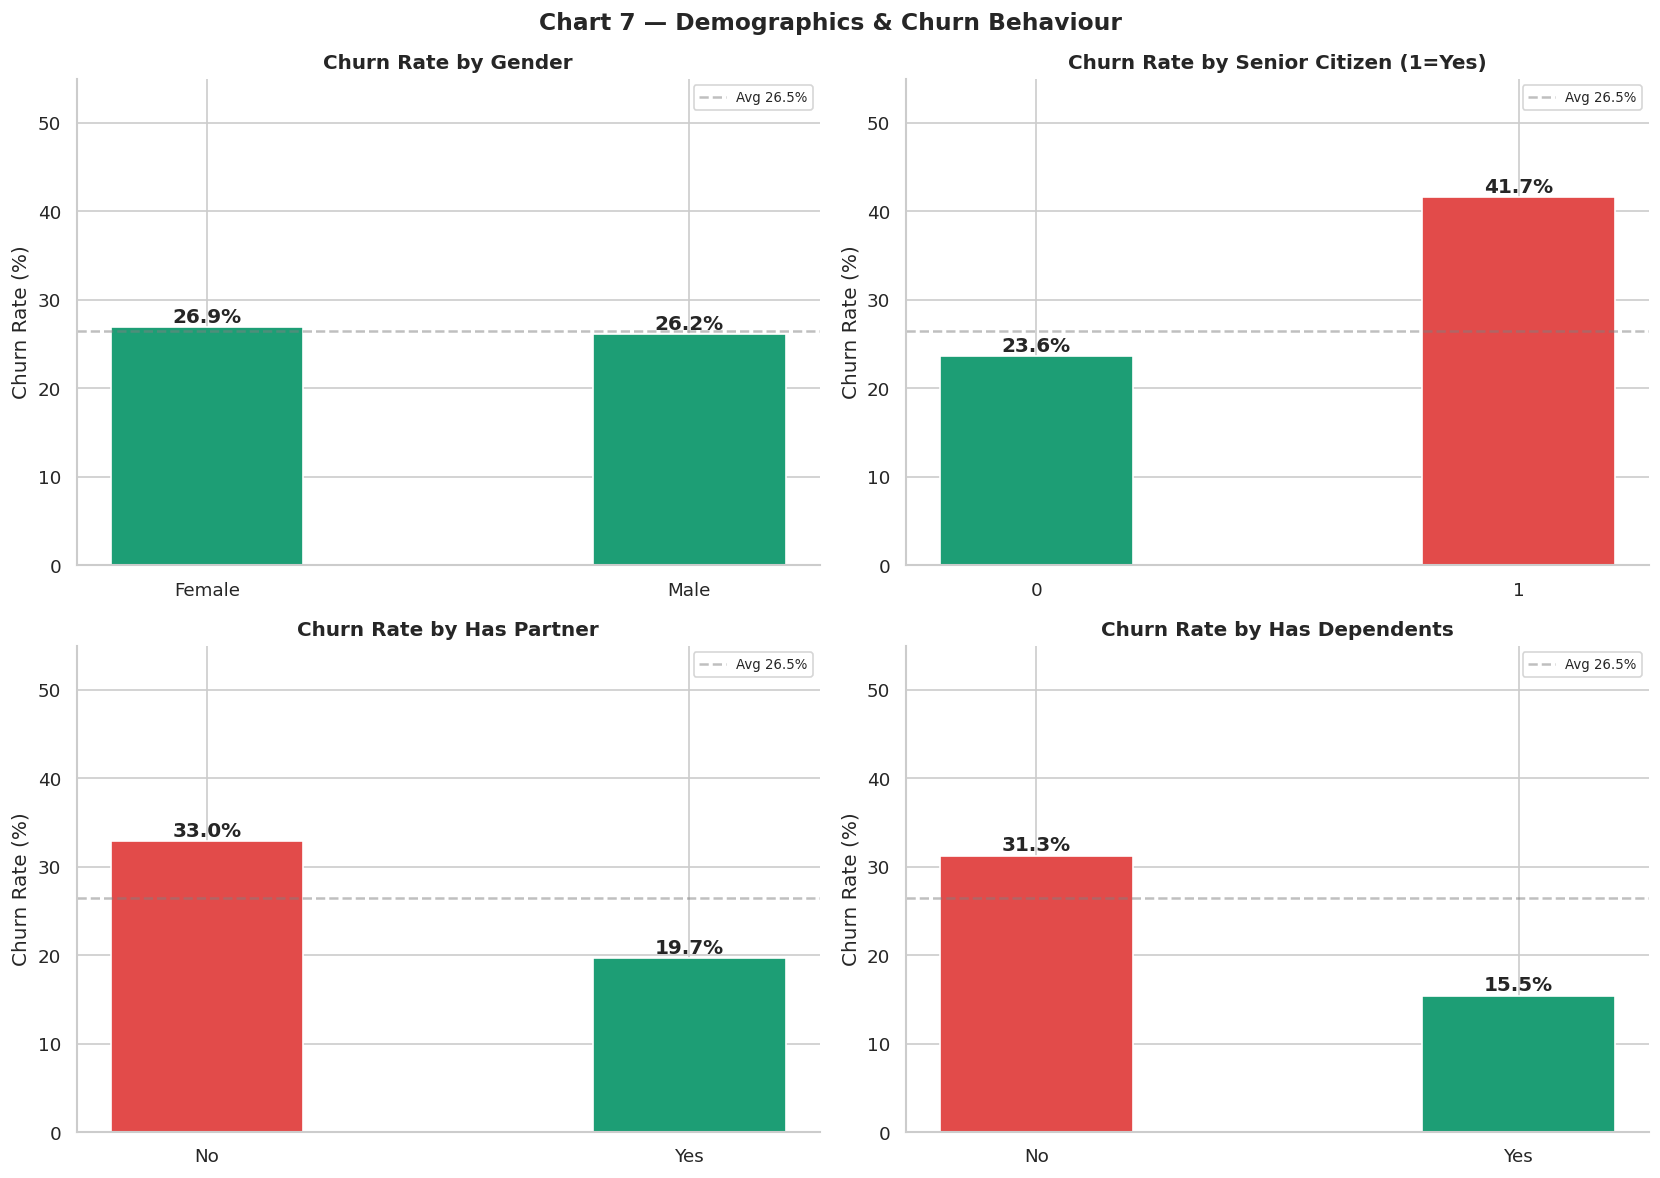

✅ Chart 7 saved — chart7_demographics.png
   🔑 Key insight: Senior citizens churn at 41.7% vs 23.6% for non-seniors


In [25]:
# ════════════════════════════════════════════════════════════
#  CHART 7 — Demographics (Gender, Senior, Partner, Dependents)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Chart 7 — Demographics & Churn Behaviour', fontsize=14, fontweight='bold')
 
demo_cols = {
    'gender':        ('Gender', axes[0][0]),
    'SeniorCitizen': ('Senior Citizen (1=Yes)', axes[0][1]),
    'Partner':       ('Has Partner', axes[1][0]),
    'Dependents':    ('Has Dependents', axes[1][1]),
}
 
for col, (title, ax) in demo_cols.items():
    churn_rate = df.groupby(col)['Churn_num'].mean() * 100
    colors_d = [C_RED if v > 30 else C_GREEN for v in churn_rate.values]
    bars = ax.bar([str(x) for x in churn_rate.index], churn_rate.values,
                   color=colors_d, width=0.4, edgecolor='white')
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
    ax.axhline(26.5, linestyle='--', color='grey', alpha=0.5, label='Avg 26.5%')
    ax.set_title(f'Churn Rate by {title}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 55)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
 
plt.tight_layout()
plt.savefig('chart7_demographics.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 7 saved — chart7_demographics.png")
print("   🔑 Key insight: Senior citizens churn at 41.7% vs 23.6% for non-seniors")
 

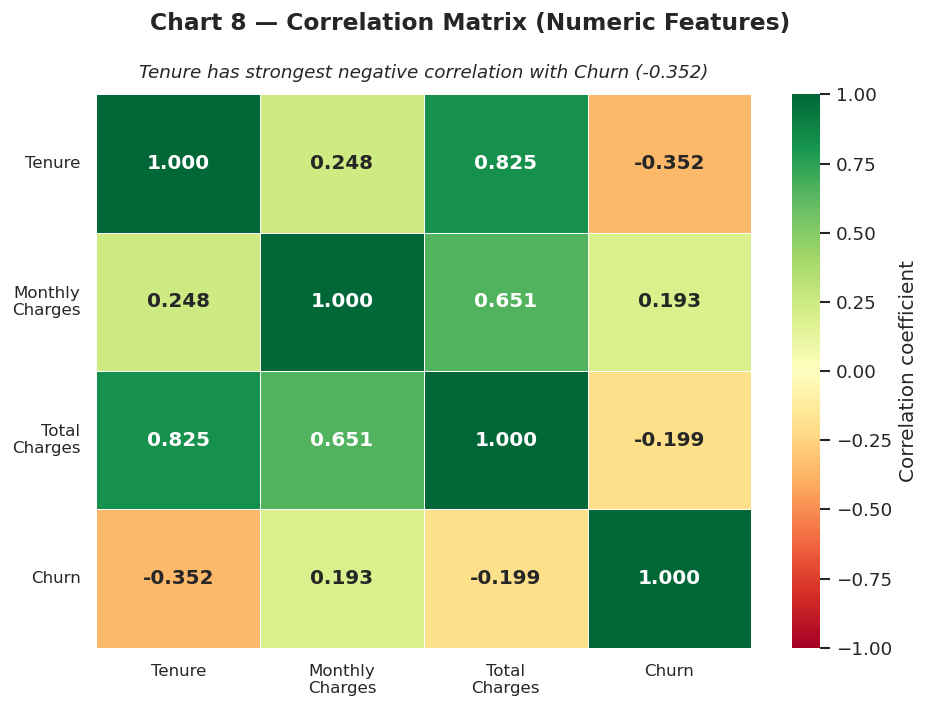

✅ Chart 8 saved — chart8_correlation_heatmap.png
   🔑 Key insight: Tenure (-0.352) is the best numeric predictor of churn


In [26]:
# ════════════════════════════════════════════════════════════
#  CHART 8 — Correlation Heatmap
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Chart 8 — Correlation Matrix (Numeric Features)', fontsize=14, fontweight='bold')
 
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
 
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'label': 'Correlation coefficient'}
)
ax.set_xticklabels(['Tenure', 'Monthly\nCharges', 'Total\nCharges', 'Churn'], fontsize=10)
ax.set_yticklabels(['Tenure', 'Monthly\nCharges', 'Total\nCharges', 'Churn'],
                    fontsize=10, rotation=0)
ax.set_title('Tenure has strongest negative correlation with Churn (-0.352)',
             fontsize=11, style='italic', pad=10)
 
plt.tight_layout()
plt.savefig('chart8_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 8 saved — chart8_correlation_heatmap.png")
print("   🔑 Key insight: Tenure (-0.352) is the best numeric predictor of churn")
 

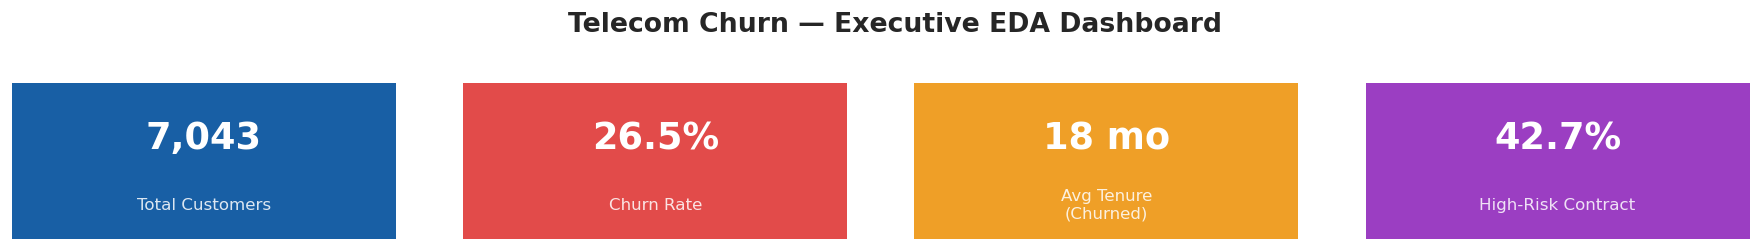

In [27]:
# ════════════════════════════════════════════════════════════
#  CHART 9 — Combined KPI Dashboard (Report-Ready)
# ════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Telecom Churn — Executive EDA Dashboard', fontsize=16, fontweight='bold', y=1.01)
 
# ── Top row: 4 KPI boxes ────────────────────────────────────
kpis = [
    ('Total Customers', '7,043',      '#185FA5'),
    ('Churn Rate',      '26.5%',      '#E24B4A'),
    ('Avg Tenure\n(Churned)', '18 mo', '#EF9F27'),
    ('High-Risk Contract', '42.7%',   '#9B3EC2'),
]
for i, (label, value, color) in enumerate(kpis):
    ax_kpi = fig.add_axes([0.04 + i * 0.235, 0.82, 0.20, 0.13])
    ax_kpi.set_facecolor(color)
    ax_kpi.text(0.5, 0.65, value,  ha='center', va='center',
                fontsize=22, fontweight='bold', color='white',
                transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.22, label,  ha='center', va='center',
                fontsize=10, color='white', alpha=0.85,
                transform=ax_kpi.transAxes)
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_visible(False)

In [28]:
 #── Bottom row: 3 key charts ────────────────────────────────
# Contract churn rate
ax1 = fig.add_axes([0.04, 0.08, 0.28, 0.65])
contract_churn = df.groupby('Contract')['Churn_num'].mean() * 100
colors_c = [C_RED, C_ORG, C_GREEN]
bars = ax1.barh(['Month-to-month', 'One year', 'Two year'],
                 contract_churn.values, color=colors_c, edgecolor='white')
for bar, val in zip(bars, contract_churn.values):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)
ax1.axvline(26.5, linestyle='--', color='grey', alpha=0.6)
ax1.set_xlim(0, 55)
ax1.set_title('Churn by Contract', fontweight='bold')
ax1.set_xlabel('Churn Rate (%)')
sns.despine(ax=ax1)

In [29]:
# Tenure histogram
ax2 = fig.add_axes([0.38, 0.08, 0.28, 0.65])
for churn_val, color, label in [('No', C_GREEN, 'Retained'), ('Yes', C_RED, 'Churned')]:
    subset = df[df['Churn'] == churn_val]['tenure']
    ax2.hist(subset, bins=25, alpha=0.65, color=color, label=label, edgecolor='white')
ax2.set_title('Tenure Distribution', fontweight='bold')
ax2.set_xlabel('Tenure (months)')
ax2.set_ylabel('Count')
ax2.legend()
sns.despine(ax=ax2)

In [30]:
 #Internet service
ax3 = fig.add_axes([0.72, 0.08, 0.26, 0.65])
internet_churn = df.groupby('InternetService')['Churn_num'].mean() * 100
colors_i2 = [C_GREEN, C_RED, C_GREEN]
bars3 = ax3.bar(internet_churn.index, internet_churn.values,
                 color=colors_i2, edgecolor='white', width=0.5)
for bar, val in zip(bars3, internet_churn.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax3.axhline(26.5, linestyle='--', color='grey', alpha=0.6)
ax3.set_title('Churn by Internet Service', fontweight='bold')
ax3.set_ylabel('Churn Rate (%)')
ax3.set_ylim(0, 55)
ax3.set_xticklabels(['DSL', 'Fiber\nOptic', 'No\nInternet'])
sns.despine(ax=ax3)
 
plt.savefig('chart9_executive_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 9 saved — chart9_executive_dashboard.png  ← PUT THIS IN YOUR REPORT")
 

<Figure size 768x576 with 0 Axes>

✅ Chart 9 saved — chart9_executive_dashboard.png  ← PUT THIS IN YOUR REPORT


In [31]:
# ════════════════════════════════════════════════════════════
#  SUMMARY OF ALL EDA FINDINGS
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  PHASE 2 COMPLETE — EDA SUMMARY")
print("="*60)
 
insights = [
    ("Overall churn rate",            "26.5%  (1,869 of 7,043 customers)"),
    ("Contract — Month-to-month",     "42.7% churn  ← #1 risk factor"),
    ("Contract — Two year",           "2.8%  churn  ← most loyal"),
    ("Internet — Fiber optic",        "41.9% churn  (vs 7.4% with no internet)"),
    ("Payment — Electronic check",    "45.3% churn  ← highest payment risk"),
    ("No OnlineSecurity",             "41.8% churn  (vs 14.6% with security)"),
    ("No TechSupport",                "41.6% churn  (vs 15.2% with support)"),
    ("Senior citizens",               "41.7% churn  (vs 23.6% non-senior)"),
    ("Avg tenure — churned",          "18 months"),
    ("Avg tenure — retained",         "38 months"),
    ("Avg monthly charges — churned", "$74.44"),
    ("Avg monthly charges — retained","$61.27"),
    ("Strongest numeric predictor",   "tenure (correlation = -0.352)"),
]
 
for label, value in insights:
    print(f"  {label:<38} {value}")
 
print("\n  Charts saved:")
for i in range(1, 10):
    names = {1:'Churn Distribution', 2:'Contract Analysis', 3:'Tenure Analysis',
             4:'Charges Analysis', 5:'Internet & Add-ons', 6:'Payment & Billing',
             7:'Demographics', 8:'Correlation Heatmap', 9:'Executive Dashboard'}
    print(f"    chart{i}_{names[i].lower().replace(' ','_')}.png")
 
print("\n  → Ready for Phase 3: Preprocessing & Feature Engineering")
 


  PHASE 2 COMPLETE — EDA SUMMARY
  Overall churn rate                     26.5%  (1,869 of 7,043 customers)
  Contract — Month-to-month              42.7% churn  ← #1 risk factor
  Contract — Two year                    2.8%  churn  ← most loyal
  Internet — Fiber optic                 41.9% churn  (vs 7.4% with no internet)
  Payment — Electronic check             45.3% churn  ← highest payment risk
  No OnlineSecurity                      41.8% churn  (vs 14.6% with security)
  No TechSupport                         41.6% churn  (vs 15.2% with support)
  Senior citizens                        41.7% churn  (vs 23.6% non-senior)
  Avg tenure — churned                   18 months
  Avg tenure — retained                  38 months
  Avg monthly charges — churned          $74.44
  Avg monthly charges — retained         $61.27
  Strongest numeric predictor            tenure (correlation = -0.352)

  Charts saved:
    chart1_churn_distribution.png
    chart2_contract_analysis.png
    chart